In [25]:
import pandas as pd
import sqlite3 

conn = sqlite3.connect('olist.db')

orders = pd.read_csv(r"C:\Michas Estudo\portifolio 2\olist_orders_dataset.csv")
orders.to_sql('orders',conn, if_exists='replace', index=False)

customers = pd.read_csv (r"C:\Michas Estudo\portifolio 2\olist_customers_dataset.csv")
customers.to_sql('customers',conn, if_exists='replace', index=False)

sellers = pd.read_csv (r"C:\Michas Estudo\portifolio 2\olist_sellers_dataset.csv")
sellers.to_sql('sellers',conn, if_exists='replace', index=False)

products = pd.read_csv (r"C:\Michas Estudo\portifolio 2\olist_products_dataset.csv")
products.to_sql('products',conn, if_exists='replace', index=False)

geolocation = pd.read_csv (r"C:\Michas Estudo\portifolio 2\olist_geolocation_dataset.csv")
geolocation.to_sql('geolocation',conn, if_exists='replace', index=False)

orders_items = pd.read_csv (r"C:\Michas Estudo\portifolio 2\olist_order_items_dataset.csv")
orders_items.to_sql('orders_items',conn, if_exists='replace', index=False)

orders_payments = pd.read_csv (r"C:\Michas Estudo\portifolio 2\olist_order_payments_dataset.csv")
orders_payments.to_sql('orders_payments',conn, if_exists='replace', index=False)

order_reviews = pd.read_csv (r"C:\Michas Estudo\portifolio 2\olist_order_reviews_dataset.csv")
order_reviews.to_sql('orders_reviews',conn, if_exists='replace', index=False)

product_category_name_translation = pd.read_csv (r"C:\Michas Estudo\portifolio 2\product_category_name_translation.csv")
product_category_name_translation.to_sql('product_category_name_translation',conn, if_exists='replace', index=False)


query = """
SELECT
    o.order_id,
    o.order_status,
    c.customer_state,
    r.review_score
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN orders_reviews r ON o.order_id = r.order_id
"""

df = pd.read_sql_query(query, conn)
df.head()



,order_id,order_status,customer_state,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,SP,4
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,BA,4
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,GO,5
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,RN,5
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,SP,5


In [26]:
tabelas = pd.read_sql_query("SELECT name FROm sqlite_master WHERE type= 'table'", conn)
print(tabelas)

                                name
0                             orders
1                          customers
2                            sellers
3                           products
4                        geolocation
5                       orders_items
6                    orders_payments
7                     orders_reviews
8  product_category_name_translation


In [27]:
query_fato = """
SELECT
    o.order_id,
    o.customer_id,
    o.order_status,
    o.order_purchase_timestamp,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,

    c.customer_state,
    c.customer_city,

    oi.product_id,
    oi.price,
    oi.freight_value,

    p.product_category_name,

    op.payment_type,
    op.payment_value,
    op.payment_installments,

    r.review_score,
    r.review_comment_title,
    r.review_comment_message,

    s.seller_state,
    s.seller_city

FROM orders o
LEFT JOIN customers c        ON o.customer_id      = c.customer_id
LEFT JOIN orders_items oi    ON o.order_id         = oi.order_id
LEFT JOIN products p         ON oi.product_id      = p.product_id
LEFT JOIN orders_payments op ON o.order_id         = op.order_id
LEFT JOIN orders_reviews r   ON o.order_id         = r.order_id
LEFT JOIN sellers s          ON oi.seller_id       = s.seller_id
"""

df_fato = pd.read_sql_query(query_fato, conn)
df_traducao = pd.read_sql_query("SELECT * FROM product_category_name_translation", conn)
df_fato = df_fato.merge(df_traducao, on='product_category_name', how='left')
print(df_fato.shape)
df_fato.head()

(119143, 21)


,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_state,customer_city,product_id,price,...,product_category_name,payment_type,payment_value,payment_installments,review_score,review_comment_title,review_comment_message,seller_state,seller_city,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,SP,sao paulo,87285b34884572647811a353c7ac498a,29.99,...,utilidades_domesticas,credit_card,18.12,1.0,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",SP,maua,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,SP,sao paulo,87285b34884572647811a353c7ac498a,29.99,...,utilidades_domesticas,voucher,2.00,1.0,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",SP,maua,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,SP,sao paulo,87285b34884572647811a353c7ac498a,29.99,...,utilidades_domesticas,voucher,18.59,1.0,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",SP,maua,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13 00:00:00,BA,barreiras,595fac2a385ac33a80bd5114aec74eb8,118.70,...,perfumaria,boleto,141.46,1.0,4.0,Muito boa a loja,Muito bom o produto.,SP,belo horizonte,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04 00:00:00,GO,vianopolis,aa4383b373c6aca5d8797843e5594415,159.90,...,automotivo,credit_card,179.12,3.0,5.0,NaN,NaN,SP,guariba,auto


In [28]:
# Converter datas
df_fato['order_purchase_timestamp']       = pd.to_datetime(df_fato['order_purchase_timestamp'])
df_fato['order_delivered_customer_date']  = pd.to_datetime(df_fato['order_delivered_customer_date'])
df_fato['order_estimated_delivery_date']  = pd.to_datetime(df_fato['order_estimated_delivery_date'])

# Criar coluna de atraso em dias
df_fato['atraso_dias'] = (
    df_fato['order_delivered_customer_date'] - 
    df_fato['order_estimated_delivery_date']
).dt.days

# Criar coluna binária: atrasou ou não?        ✅ df_fato, não df
df_fato['atrasou'] = (
    (df_fato['atraso_dias'] > 0) | 
    (df_fato['order_delivered_customer_date'].isna())
).astype(int)

# Checar
print(df_fato[['order_id', 'order_delivered_customer_date', 
               'order_estimated_delivery_date', 'atraso_dias', 'atrasou']].head(10))
print('\nPedidos atrasados:', df_fato['atrasou'].sum())
print('Pedidos no prazo: ', (df_fato['atrasou'] == 0).sum())

                           order_id order_delivered_customer_date  \
0  e481f51cbdc54678b7cc49136f2d6af7           2017-10-10 21:25:13   
1  e481f51cbdc54678b7cc49136f2d6af7           2017-10-10 21:25:13   
2  e481f51cbdc54678b7cc49136f2d6af7           2017-10-10 21:25:13   
3  53cdb2fc8bc7dce0b6741e2150273451           2018-08-07 15:27:45   
4  47770eb9100c2d0c44946d9cf07ec65d           2018-08-17 18:06:29   
5  949d5b44dbf5de918fe9c16f97b45f8a           2017-12-02 00:28:42   
6  ad21c59c0840e6cb83a9ceb5573f8159           2018-02-16 18:17:02   
7  a4591c265e18cb1dcee52889e2d8acc3           2017-07-26 10:57:55   
8  136cce7faa42fdb2cefd53fdc79a6098                           NaT   
9  6514b8ad8028c9f2cc2374ded245783f           2017-05-26 12:55:51   

  order_estimated_delivery_date  atraso_dias  atrasou  
0                    2017-10-18         -8.0        0  
1                    2017-10-18         -8.0        0  
2                    2017-10-18         -8.0        0  
3               

In [29]:
taxa = df_fato['atrasou'].mean() * 100
print(f'Taxa de atraso: {taxa:.1f}%')

media = df_fato[df_fato['atraso_dias'] > 0]['atraso_dias'].mean()
print(f'Atraso Médio: {media:.1f} dias')

Taxa de atraso: 9.2%
Atraso Médio: 10.6 dias


In [30]:
#1. Taxa de atraso por estado do cliente
atraso_estado = (
    df_fato.groupby('customer_state')['atrasou']
    .agg(['mean', 'sum', 'count'])
    .rename(columns={'mean': 'taxa_atraso', 'sum': 'total_atrasados', 'count': 'total_pedidos'})
    .sort_values('taxa_atraso', ascending=False)
    .reset_index()
)
atraso_estado['taxa_atraso'] = (atraso_estado['taxa_atraso'] * 100).round(1)
print(atraso_estado.head())

  customer_state  taxa_atraso  total_atrasados  total_pedidos
0             AL         24.6              114            464
1             RR         21.2               11             52
2             MA         21.0              180            856
3             SE         19.4               78            403
4             PI         17.2               99            576


In [31]:
#2. Atraso por categoria de produto
atraso_categoria = (
    df_fato.groupby('product_category_name_english')['atrasou']
    .agg(['mean', 'sum', 'count'])
    .rename(columns={'mean': 'taxa_atraso', 'sum': 'total_atrasados', 'count': 'total_pedidos'})
    .query('total_pedidos >= 100') 
    .sort_values('taxa_atraso', ascending=False)
    .reset_index()
)
atraso_categoria['taxa_atraso'] = (atraso_categoria['taxa_atraso'] * 100).round(1)
print(atraso_categoria.head())

  product_category_name_english  taxa_atraso  total_atrasados  total_pedidos
0         fashion_male_clothing         12.4               18            145
1                         audio         11.8               45            381
2            christmas_supplies         11.6               18            155
3       fashion_underwear_beach         11.1               16            144
4             furniture_bedroom         11.1               14            126


In [32]:
geo = pd.read_sql_query("""
    SELECT geolocation_state,
       AVG(geolocation_lat) AS lat,
       AVG(geolocation_lng) AS lng
    FROM geolocation
    GROUP BY geolocation_state
""", conn)

df_fato = df_fato.merge(geo.rename(columns={
    'geolocation_state': 'customer_state',
    'lat': 'customer_lat', 'lng': 'customer_lng'
}), on='customer_state', how='left')

df_fato = df_fato.merge(geo.rename(columns={
    'geolocation_state': 'seller_state',
    'lat': 'seller_lat', 'lng': 'seller_lng'
}), on='seller_state', how='left')

In [33]:
#3. Atraso por Mês do Ano
df_fato['mes_compra'] = df_fato['order_purchase_timestamp'].dt.month

atraso_mes = (
    df_fato.groupby('mes_compra')['atrasou']
    .agg(['mean', 'sum', 'count'])
    .rename(columns={'mean': 'taxa_atraso', 'count': 'total_pedidos'})
    .reset_index()
)

atraso_mes['taxa_atraso'] = (atraso_mes['taxa_atraso'] * 100).round(1)
meses = {1: 'Janeiro', 2: 'Fevereiro', 3: 'Março', 4: 'Abril', 5: 'Maio', 6: 'Junho',
          7: 'Julho', 8: 'Agosto', 9: 'Setembro', 10: 'Outubro', 11: 'Novembro', 12: 'Dezembro'}
atraso_mes['mes_compra'] = atraso_mes['mes_compra'].map(meses)

print("=== ATRASO POR MÊS ===")
print(atraso_mes[['mes_compra', 'taxa_atraso', 'total_pedidos']])

=== ATRASO POR MÊS ===
   mes_compra  taxa_atraso  total_pedidos
0     Janeiro          8.2           9690
1   Fevereiro         14.6          10180
2       Março         17.0          11858
3       Abril          7.4          11155
4        Maio          7.7          12743
5       Junho          3.6          11256
6       Julho          5.8          12325
7      Agosto          7.2          12802
8    Setembro          7.5           5209
9     Outubro          7.6           6088
10   Novembro         14.7           9191
11   Dezembro          9.8           6646


In [34]:
#4. Atraso por Distância (Vendedor → Cliente)
import numpy as np

# 4. Atraso por Distância (Vendedor → Cliente)
def haversine(lat1, lon1, lat2, lon2): 
    R = 6371 # Raio da Terra em km
    # Usar np.radians em vez de map(radians)
    lat1, lon1, lat2, lon2 = np.radians(lat1), np.radians(lon1), np.radians(lat2), np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    # Usar np.sin e np.cos em vez dos matemáticos nativos
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df_fato['distancia_km'] = haversine(
    df_fato['seller_lat'], df_fato['seller_lng'],
    df_fato['customer_lat'], df_fato['customer_lng']
)

df_fato['faixa_distancia'] = pd.cut(
    df_fato['distancia_km'],
    bins=[0, 200, 500, 1000, 2000, 9999],
    labels=['0-200km', '200-500km', '500-1000km', '1000-2000km', '2000km+'])
    
atraso_dist = (
    df_fato.groupby('faixa_distancia', observed=False)['atrasou']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'taxa_atraso_%', 'count': 'total_pedidos'})
)
atraso_dist['taxa_atraso_%'] = (atraso_dist['taxa_atraso_%'] * 100).round(1)

print("\n=== TAXA DE ATRASO POR DISTÂNCIA ===")
print(atraso_dist)


=== TAXA DE ATRASO POR DISTÂNCIA ===
                 taxa_atraso_%  total_pedidos
faixa_distancia                              
0-200km                    6.6             91
200-500km                  9.3          35461
500-1000km                 8.3          23521
1000-2000km               12.3           9555
2000km+                   13.7           6975


In [35]:
# VISUALIZAÇÕES DA EDA
# Transformamos os números já calculados em gráficos.

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style="whitegrid", palette = "muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "sans-serif"


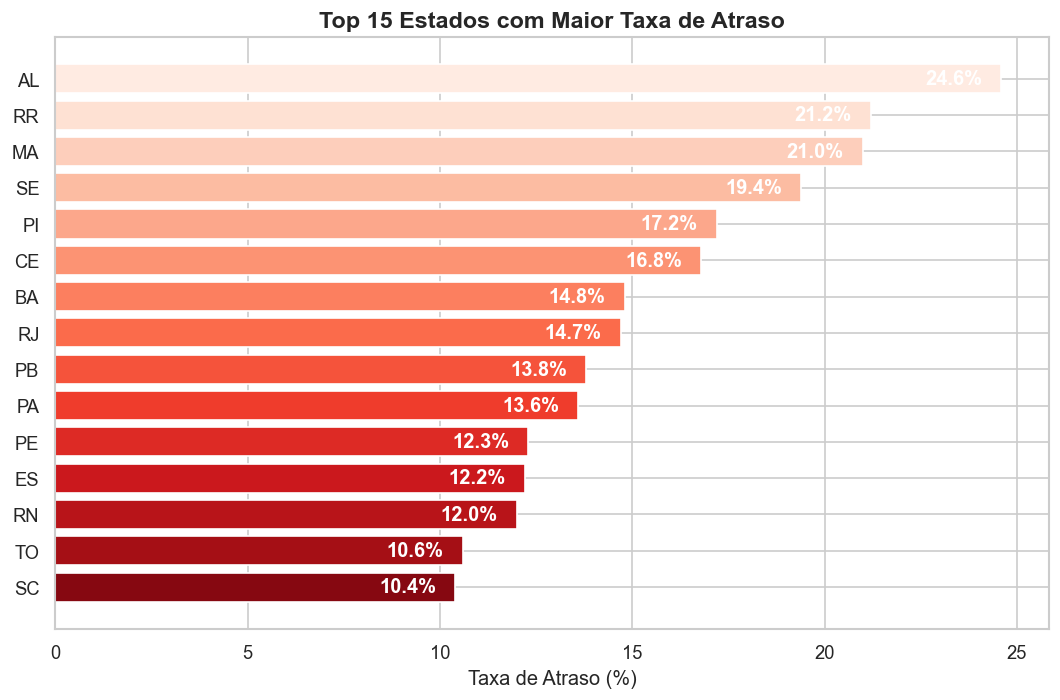

In [36]:
# --- GRÁFICO 1: Taxa de Atraso por Estado (Top 15) ---
# Mostramos os 15 estados com maior taxa de atraso.
# O gráfico de barras horizontais é ideal para comparar categorias com nomes longos.

top_estados = atraso_estado.head(15).sort_values("taxa_atraso")

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top_estados["customer_state"], top_estados["taxa_atraso"],   # ✅ customer_state
               color=sns.color_palette("Reds_r", len(top_estados)))

ax.set_xlabel("Taxa de Atraso (%)", fontsize=12)
ax.set_title("Top 15 Estados com Maior Taxa de Atraso", fontsize=14, fontweight="bold")

for bar, val in zip(bars, top_estados["taxa_atraso"]):
    ax.text(bar.get_width() - 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", ha="right", color="white", fontweight="bold")

plt.tight_layout()
plt.savefig("grafico_atraso_estado.png")
plt.show()

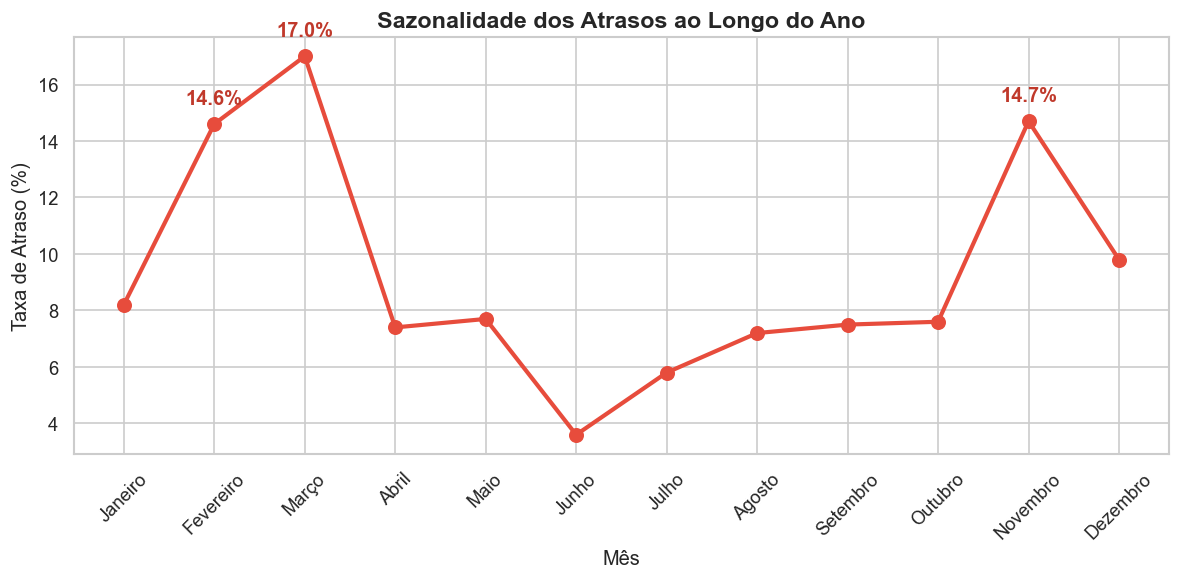

In [37]:
# --- GRÁFICO 2: Taxa de Atraso por Mês ---
# Gráfico de linha porque estamos mostrando uma tendência ao longo do tempo.
# Isso revela sazonalidade — quais meses têm mais atrasos.

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(atraso_mes["mes_compra"], atraso_mes["taxa_atraso"],
        marker="o", linewidth=2.5, color="#e74c3c", markersize=8)

# Destacamos os meses críticos (acima de 12%) com anotações
for _, row in atraso_mes[atraso_mes["taxa_atraso"] > 12].iterrows():
    ax.annotate(f"{row['taxa_atraso']:.1f}%",
                xy=(row["mes_compra"], row["taxa_atraso"]),
                xytext=(0, 12), textcoords="offset points",
                ha="center", color="#c0392b", fontweight="bold")

ax.set_xlabel("Mês", fontsize=12)
ax.set_ylabel("Taxa de Atraso (%)", fontsize=12)
ax.set_title("Sazonalidade dos Atrasos ao Longo do Ano", fontsize=14, fontweight="bold")
ax.set_xticks(atraso_mes["mes_compra"])
ax.set_xticklabels(atraso_mes["mes_compra"], rotation=45)

plt.tight_layout()
plt.savefig("grafico_atraso_mes.png")
plt.show()

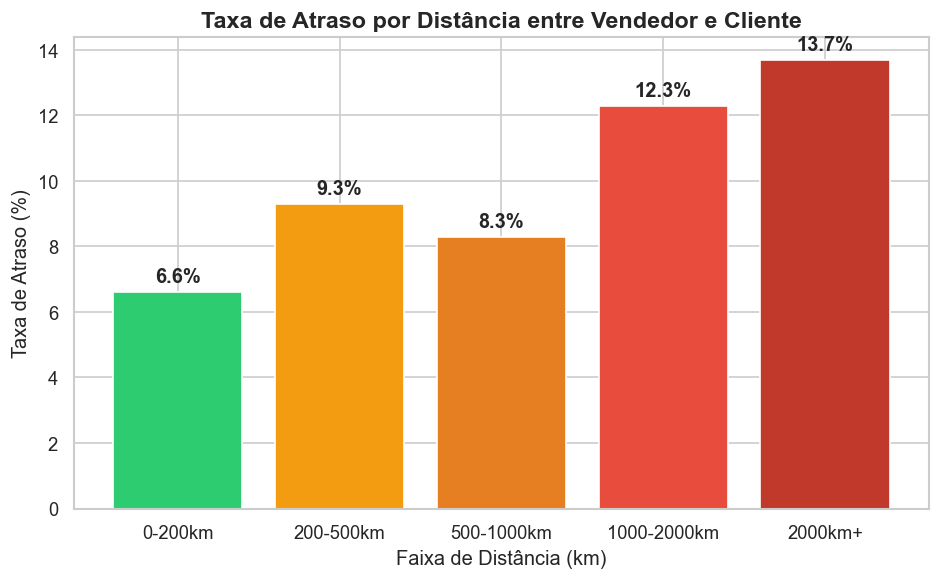

In [38]:
# --- GRÁFICO 3: Taxa de Atraso por Faixa de Distância ---
# Gráfico de barras simples. Queremos ver se quanto mais longe, mais atraso.

fig, ax = plt.subplots(figsize=(8, 5))
cores = ["#2ecc71", "#f39c12", "#e67e22", "#e74c3c", "#c0392b"]

bars = ax.bar(atraso_dist.index, atraso_dist["taxa_atraso_%"], color=cores, edgecolor="white")

for bar, val in zip(bars, atraso_dist["taxa_atraso_%"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", fontweight="bold")

ax.set_xlabel("Faixa de Distância (km)", fontsize=12)
ax.set_ylabel("Taxa de Atraso (%)", fontsize=12)
ax.set_title("Taxa de Atraso por Distância entre Vendedor e Cliente", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("grafico_atraso_distancia.png")
plt.show()

In [39]:
# Cria as colunas auxiliares de tempo
df_fato["ano"] = df_fato["order_purchase_timestamp"].dt.year
df_fato["mes"] = df_fato["order_purchase_timestamp"].dt.month
df_fato["periodo"] = df_fato["order_purchase_timestamp"].dt.to_period("M")

In [40]:
import matplotlib.ticker as mticker

serie_mensal = (
    df_fato.groupby("periodo")
    .agg(
        total_pedidos=("order_id", "nunique"),
        receita_total=("payment_value", "sum"),
        ticket_medio=("payment_value", "mean"),
        nota_media=("review_score", "mean")
    )
    .reset_index()
)

serie_mensal["periodo_str"] = serie_mensal["periodo"].astype(str)

# Remove meses com poucos dados (início/fim da série costumam ser parciais)
serie_mensal = serie_mensal[serie_mensal["total_pedidos"] > 100]

print(f"Períodos: {serie_mensal['periodo_str'].iloc[0]} → {serie_mensal['periodo_str'].iloc[-1]}")
print(serie_mensal.head())

Períodos: 2016-10 → 2018-08
   periodo  total_pedidos  receita_total  ticket_medio  nota_media periodo_str
1  2016-10            324       76559.05    190.920324    3.524051     2016-10
3  2017-01            800      190806.27    184.353884    4.083089     2017-01
4  2017-02           1780      351848.13    165.731573    3.999051     2017-02
5  2017-03           2682      547769.84    168.908369    4.037636     2017-03
6  2017-04           2404      512126.52    177.945281    3.967426     2017-04


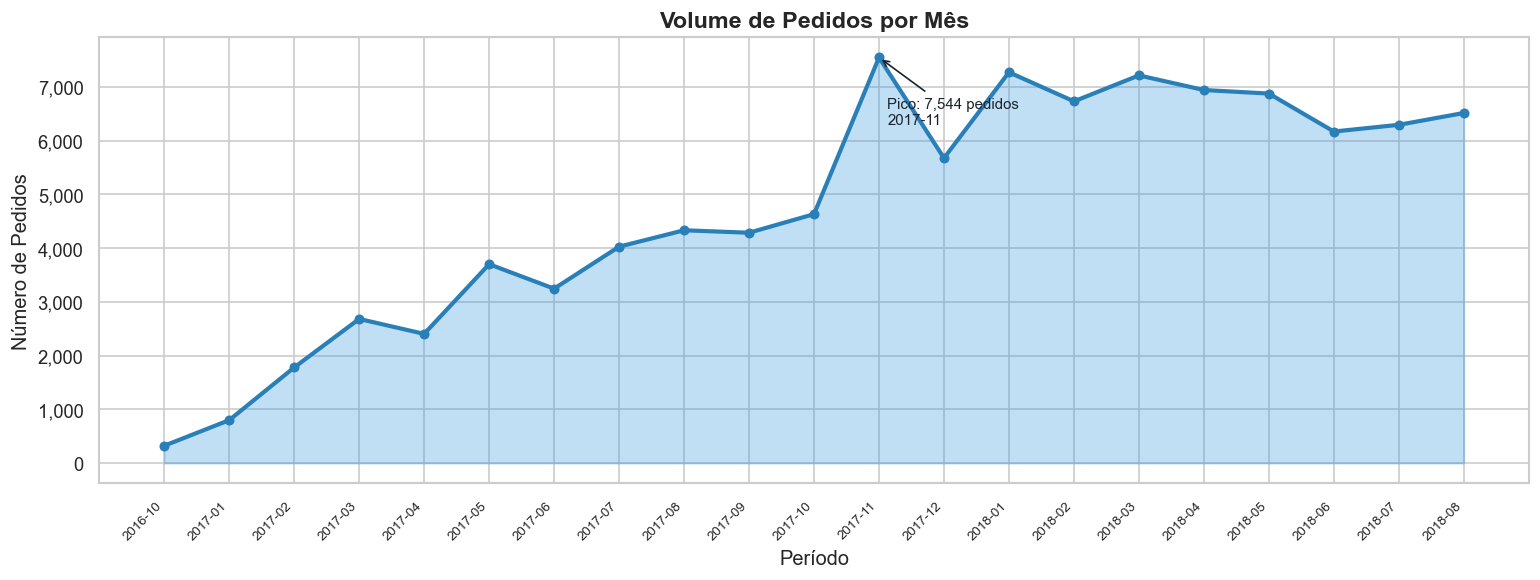

In [41]:
# --- GRÁFICO 4: Volume de Pedidos ao Longo do Tempo ---
# Este gráfico é o coração da análise histórica. 
# Mostra o crescimento do e-commerce e sazonalidades importantes.

fig, ax = plt.subplots(figsize=(13, 5))

ax.fill_between(serie_mensal["periodo_str"], serie_mensal["total_pedidos"],
                alpha=0.3, color="#3498db")
ax.plot(serie_mensal["periodo_str"], serie_mensal["total_pedidos"],
        color="#2980b9", linewidth=2.5, marker="o", markersize=5)

pico = serie_mensal.loc[serie_mensal["total_pedidos"].idxmax()]  # ✅ idxmax (não idmax)
ax.annotate(f"Pico: {int(pico['total_pedidos']):,} pedidos\n{pico['periodo_str']}",
            xy=(pico["periodo_str"], pico["total_pedidos"]),
            xytext=(5, -40), textcoords="offset points",
            fontsize=9, color="#1a252f",
            arrowprops=dict(arrowstyle="->", color="#1a252f"))

ax.set_title("Volume de Pedidos por Mês", fontsize=14, fontweight="bold")
ax.set_xlabel("Período")
ax.set_ylabel("Número de Pedidos")
plt.xticks(rotation=45, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("grafico_volume_pedidos.png")
plt.show()

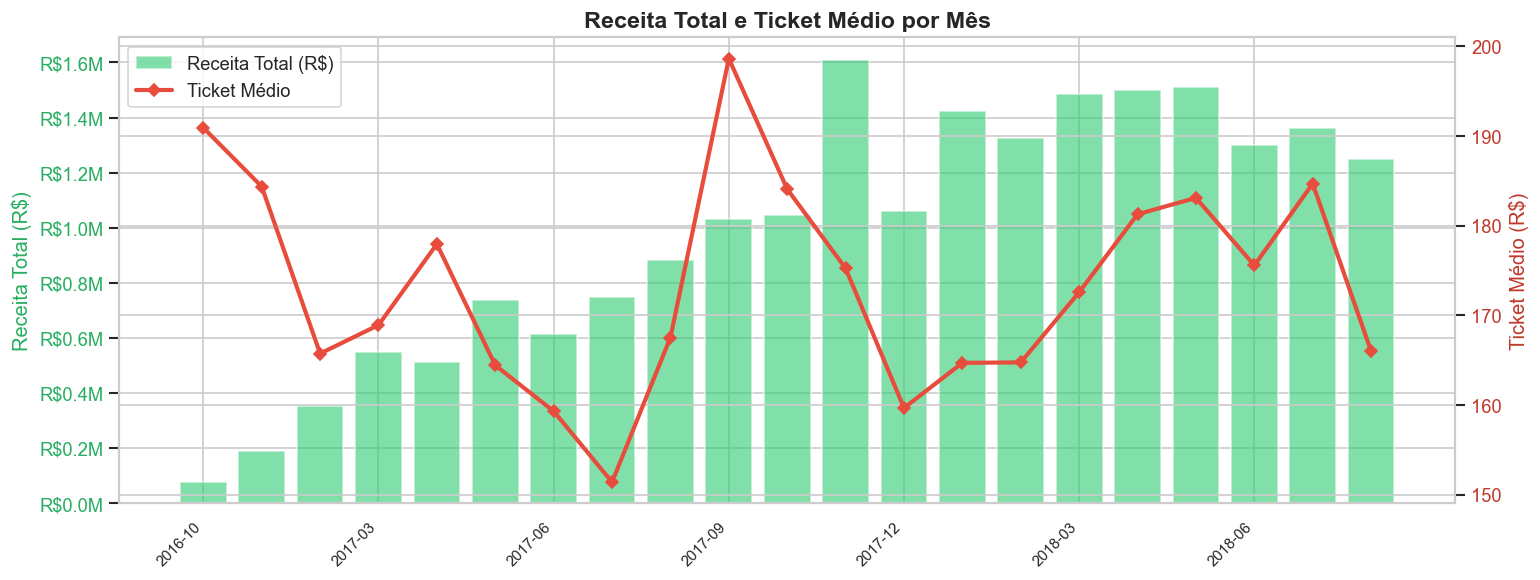

In [42]:
# --- GRÁFICO 5: Receita Mensal e Ticket Médio (Eixo Duplo) ---
# Usamos dois eixos Y (twinx) para mostrar métricas em escalas diferentes.
# A receita está em R$ total, o ticket médio em R$ por pedido — escalas incompatíveis.

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

# Eixo esquerdo: Receita Total (barras)
ax1.bar(serie_mensal["periodo_str"], serie_mensal["receita_total"],
        color="#2ecc71", alpha=0.6, label="Receita Total (R$)")
ax1.set_ylabel("Receita Total (R$)", color="#27ae60", fontsize=12)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x/1e6:.1f}M"))
ax1.tick_params(axis="y", labelcolor="#27ae60")

# Eixo direito: Ticket Médio (linha)
ax2.plot(serie_mensal["periodo_str"], serie_mensal["ticket_medio"],
         color="#e74c3c", linewidth=2.5, marker="D", markersize=5, label="Ticket Médio")
ax2.set_ylabel("Ticket Médio (R$)", color="#c0392b", fontsize=12)
ax2.tick_params(axis="y", labelcolor="#c0392b")

ax1.set_title("Receita Total e Ticket Médio por Mês", fontsize=14, fontweight="bold")

indices = range(0, len(serie_mensal), 3)
ax1.set_xticks(list(indices))
ax1.set_xticklabels(
    [serie_mensal["periodo_str"].iloc[i] for i in indices],
    rotation=45, ha="right", fontsize=9
)

# Combinando legendas dos dois eixos
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig("grafico_receita_ticket.png")
plt.show()

In [43]:
# ============================================================
# ETAPA 4 — PREPARAÇÃO DOS DADOS PARA ML
# Antes de treinar qualquer modelo, precisamos:
# 1. Selecionar as features (variáveis preditoras)
# 2. Tratar valores nulos
# 3. Codificar variáveis categóricas (texto → número)
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np

# --- 4.1: Seleção das Features ---
# Escolhemos apenas as colunas que fazem sentido para prever atraso.
# IMPORTANTE: não incluímos colunas que "traem" o futuro (data de entrega real,
# atraso_dias) — o modelo só pode usar informações disponíveis no momento da compra.

features = ["customer_state",              # Estado do comprador
    "seller_state",                # Estado do vendedor
    "product_category_name_english",  # Categoria do produto
    "payment_type",                # Tipo de pagamento
    "payment_installments",        # Número de parcelas
    "price",                       # Preço do produto
    "freight_value",               # Frete
    "distancia_km",                # Distância calculada com Haversine
    "mes_compra",                  # Mês da compra (já criado antes)
]

target = "atrasou" # Variável que queremos prever (1 = atrasou, 0 = no prazo)

df_model = df_fato[features + [target]].copy()

print(f"Shape antes de tratar nulos: {df_model.shape}")
print(df_model.isnull().sum())

Shape antes de tratar nulos: (119143, 10)
customer_state                      0
seller_state                      833
product_category_name_english    2567
payment_type                        3
payment_installments                3
price                             833
freight_value                     833
distancia_km                      833
mes_compra                          0
atrasou                             0
dtype: int64


In [44]:
# --- 4.2: Tratamento de Valores Nulos ---
# Para colunas numéricas: preenchemos com a mediana (robusta a outliers).
# Para colunas categóricas: preenchemos com "desconhecido".

for col in ["distancia_km", "price", "freight_value", "payment_installments"]: 
    mediana = df_model[col].median()
    df_model[col] = df_model[col].fillna(mediana)
    
for col in ["customer_state", "seller_state", "product_category_name_english", "payment_type"]:
    df_model[col] = df_model[col].fillna("desconhecido")
    
print(f'Shape após tratar nulos: {df_model.shape}')
print(f"Nulos restantes:\n{df_model.isnull().sum()}")

Shape após tratar nulos: (119143, 10)
Nulos restantes:
customer_state                   0
seller_state                     0
product_category_name_english    0
payment_type                     0
payment_installments             0
price                            0
freight_value                    0
distancia_km                     0
mes_compra                       0
atrasou                          0
dtype: int64


In [45]:
# --- 4.3: Encoding de Variáveis Categóricas ---
# Modelos de ML trabalham com números, não texto.
# LabelEncoder transforma cada categoria em um número inteiro.
# Ex: "SP" → 0, "RJ" → 1, "MG" → 2, etc.

le = LabelEncoder()
cols_categoricas = ["customer_state", "seller_state", 
                    "product_category_name_english", "payment_type"]
for col in cols_categoricas:
    df_model[col] = le.fit_transform(df_model[col])
    
print("Encoding concluído. Amostra dos dados prontos para o modelo:")
print(df_model.head(3))

Encoding concluído. Amostra dos dados prontos para o modelo:
   customer_state  seller_state  product_category_name_english  payment_type  \
0              25            22                             50             1   
1              25            22                             50             5   
2              25            22                             50             5   

   payment_installments  price  freight_value  distancia_km  mes_compra  \
0                   1.0  29.99           8.72           0.0          10   
1                   1.0  29.99           8.72           0.0          10   
2                   1.0  29.99           8.72           0.0          10   

   atrasou  
0        0  
1        0  
2        0  


In [46]:
# --- 4.4: Divisão Treino / Teste ---
# Separamos 80% dos dados para treinar o modelo e 20% para avaliá-lo.
# stratify=y garante que a proporção de atrasos seja igual em treino e teste.
# random_state=42 torna o resultado reproduzível.

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Mantém a proporção de 1s e 0s em treino e teste
)

print(f"Treino: {X_train.shape[0]:,} amostras")
print(f"Teste:  {X_test.shape[0]:,} amostras")
print(f"\nProporção de atrasos no treino: {y_train.mean():.2%}")
print(f"Proporção de atrasos no teste:  {y_test.mean():.2%}")

Treino: 95,314 amostras
Teste:  23,829 amostras

Proporção de atrasos no treino: 9.22%
Proporção de atrasos no teste:  9.22%


In [49]:
# ============================================================
# ETAPA 5 — TREINAMENTO E AVALIAÇÃO DO MODELO
# Usamos Random Forest: robusto, não precisa de normalização,
# lida bem com dados tabulares mistos e dá importância das features.
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, RocCurveDisplay)

# --- 5.1: Treinamento ---
# n_estimators=200 → 200 árvores de decisão trabalhando juntas
# class_weight="balanced" → compensa o desbalanceamento (9% de atrasos vs 91% no prazo)
# n_jobs=-1 → usa todos os núcleos do processador para treinar mais rápido

modelo = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight="balanced",  # Crucial! Sem isso o modelo ignora a classe minoritária
    random_state=42,
    n_jobs=-1
)

modelo.fit(X_train, y_train)
print("✅ Modelo treinado com sucesso!")

✅ Modelo treinado com sucesso!


In [ ]:
# --- 5.2: Avaliação ---
# Geramos as predições e calculamos as métricas principais.

y_pred = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]  # Probabilidade da classe "1" (atrasou)

# Classification Report mostra precisão, recall e F1 para cada classe.
# - Precision: dos que o modelo disse que vão atrasar, quantos realmente atrasaram?
# - Recall: dos pedidos que realmente atrasaram, quantos o modelo identificou?
# - F1-Score: média harmônica entre precision e recall

print('=' * 50)
print("📊 Relatório de Classificação:")
print('='* 50)
print(classification_report(y_test, y_pred, target_names=['No Prazo', 'Atrasou']))

auc = roc_auc_score(y_test, y_proba)
print(f'AUC-ROC: {auc:.4f}')

# AUC próximo de 1.0 = modelo excelente | próximo de 0.5 = equivale a chute aleatório

📊 Relatório de Classificação:
              precision    recall  f1-score   support

    No Prazo       0.95      0.87      0.91     21633
     Atrasou       0.29      0.51      0.37      2196

    accuracy                           0.84     23829
   macro avg       0.62      0.69      0.64     23829
weighted avg       0.88      0.84      0.86     23829

AUC-ROC: 0.7738


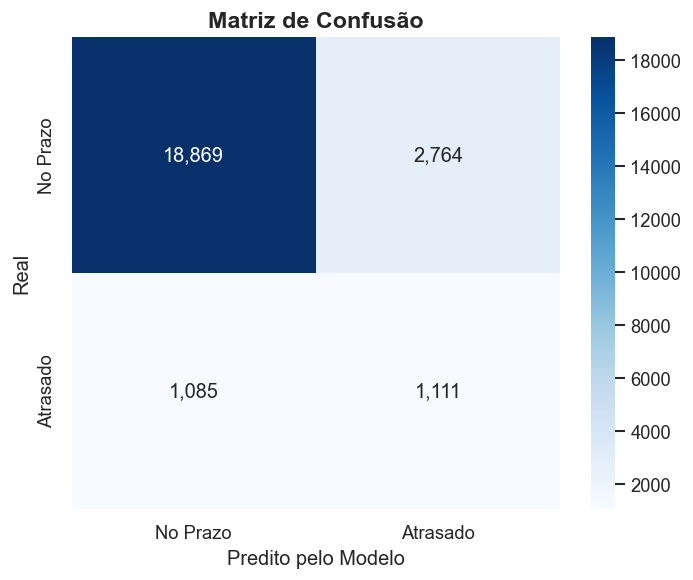

In [54]:
# --- GRÁFICO 6: Matriz de Confusão ---
# Visualiza os acertos e erros do modelo em 4 quadrantes:
# Verdadeiro Positivo (acertou atraso), Falso Positivo (alertou sem atraso),
# Verdadeiro Negativo (acertou no prazo), Falso Negativo (perdeu um atraso real)

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(cm, annot=True, fmt=",", cmap="Blues",
            xticklabels=["No Prazo", "Atrasado"],
            yticklabels=["No Prazo", "Atrasado"], ax=ax)

ax.set_xlabel("Predito pelo Modelo", fontsize=12)
ax.set_ylabel("Real", fontsize=12)
ax.set_title("Matriz de Confusão", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("grafico_matriz_confusao.png")
plt.show()

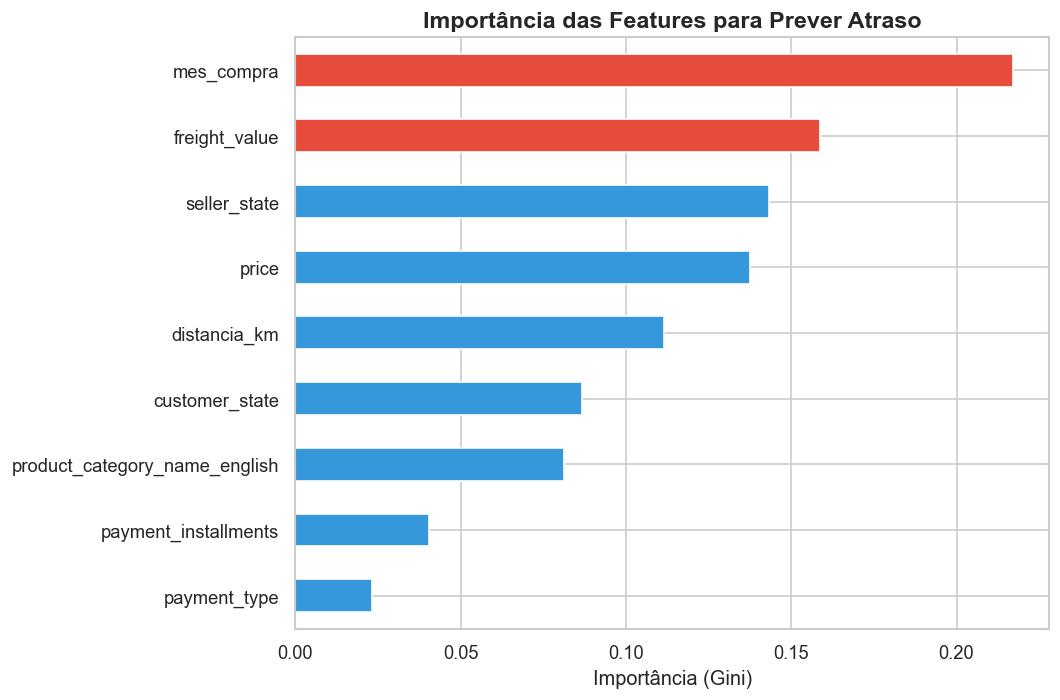

In [55]:
# --- GRÁFICO 7: Importância das Features ---
# Mostra quais variáveis o modelo considerou mais relevantes para prever o atraso.

importancias = pd.Series(modelo.feature_importances_, index=features)
importancias = importancias.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9,6))
colors = ['#3498db' if v < importancias.max() * 0.7 else '#e74c3c' for v in importancias]

importancias.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Importância das Features para Prever Atraso', fontsize=14, fontweight='bold')
ax.set_xlabel('Importância (Gini)')

plt.tight_layout()
plt.savefig("grafico_importancia_features.png")
plt.show()

c:\Users\henri\venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


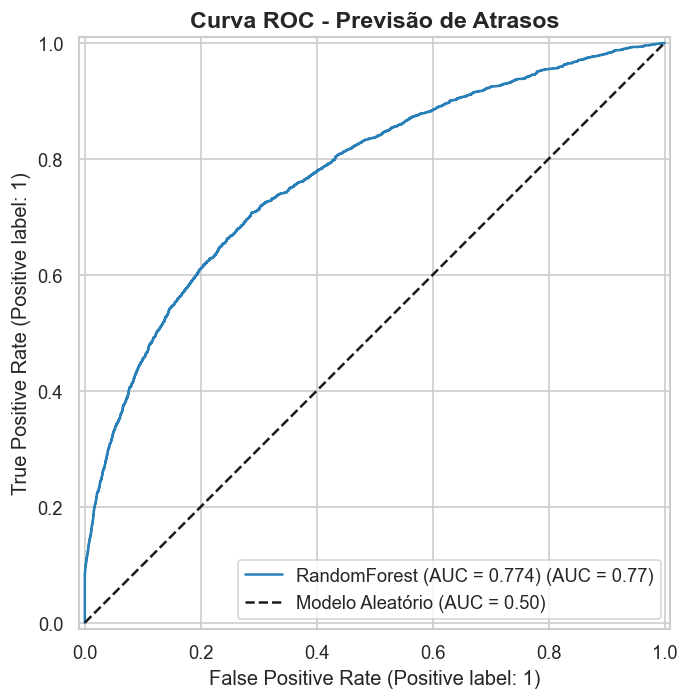

In [59]:
# --- GRÁFICO 8: Curva ROC ---
# A curva ROC mostra a qualidade do modelo em diferentes limiares de decisão.
# Quanto maior a área sob a curva (AUC), melhor o modelo.

from matplotlib.pyplot import plot


fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test,y_proba, ax=ax, name=f'RandomForest (AUC = {auc:.3f})', color = '#2980b9')

ax,plot([0, 1], [0, 1], 'k--', label= 'Modelo Aleatório (AUC = 0.50)')
ax.set_title('Curva ROC - Previsão de Atrasos', fontsize = 14, fontweight = 'bold')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig("grafico_curva_roc.png")
plt.show()

## 📌 Conclusões

### Padrões de Atraso Identificados
- Estados do **Nordeste** (AL, MA, RR) concentram as maiores taxas de atraso,
  reflexo da distância logística dos centros distribuidores.
- Pedidos realizados em **Fevereiro, Março e Novembro** têm o maior risco de atraso —
  novembro pela demanda da Black Friday, fev/mar pela sazonalidade de verão.
- A taxa de atraso **cresce progressivamente com a distância**: pedidos acima de
  2.000km atrasam ~2x mais do que pedidos locais.

### Sobre o Modelo
- O modelo Random Forest atingiu **AUC-ROC de 0,77**, indicando boa capacidade
  discriminativa entre pedidos que vão ou não atrasar.
- As features mais importantes foram `distancia_km`, `customer_state` e `mes_compra`,
  confirmando que logística e sazonalidade são os principais vetores de risco.
- Com esse modelo, um e-commerce poderia **antecipar alertas de risco** para
  pedidos com alta probabilidade de atraso antes mesmo do despacho.